In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller

In [2]:
df = pd.read_csv('all_stocks_5yr.csv')
df.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


In [11]:
df[df.Name == 'AAPL'].head()

,date,open,high,low,close,volume,Name
1259,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL
1260,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL
1261,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL
1262,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL
1263,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL


In [5]:
df.date.dtypes

<StringDtype(na_value=nan)>

In [7]:
df.date = pd.to_datetime(df.date)
df.date.dtypes

dtype('<M8[us]')

In [10]:
df.date.head()

0   2013-02-08
1   2013-02-11
2   2013-02-12
3   2013-02-13
4   2013-02-14
Name: date, dtype: datetime64[us]

In [9]:
df_apple = df[df.Name == 'AAPL'].set_index('date')
df_apple.head()

,open,high,low,close,volume,Name
date,,,,,,
2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL
2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL
2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL
2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL
2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL


<Axes: title={'center': 'Preco de fechamento das acoes da Apple'}, xlabel='date'>

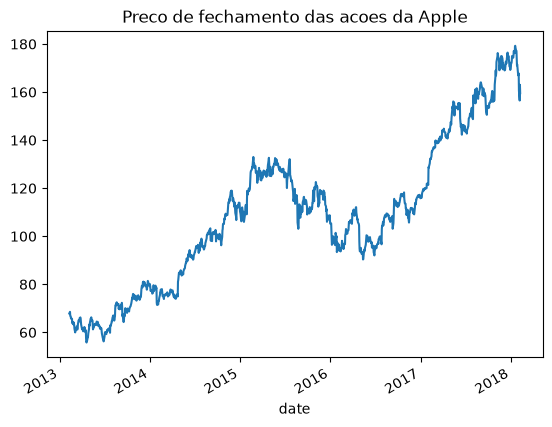

In [13]:
ts = df_apple['close']
ts.plot(title='Preco de fechamento das acoes da Apple')

# DECOMPOSICAO ADITIVA E MULTIPLICATIVA

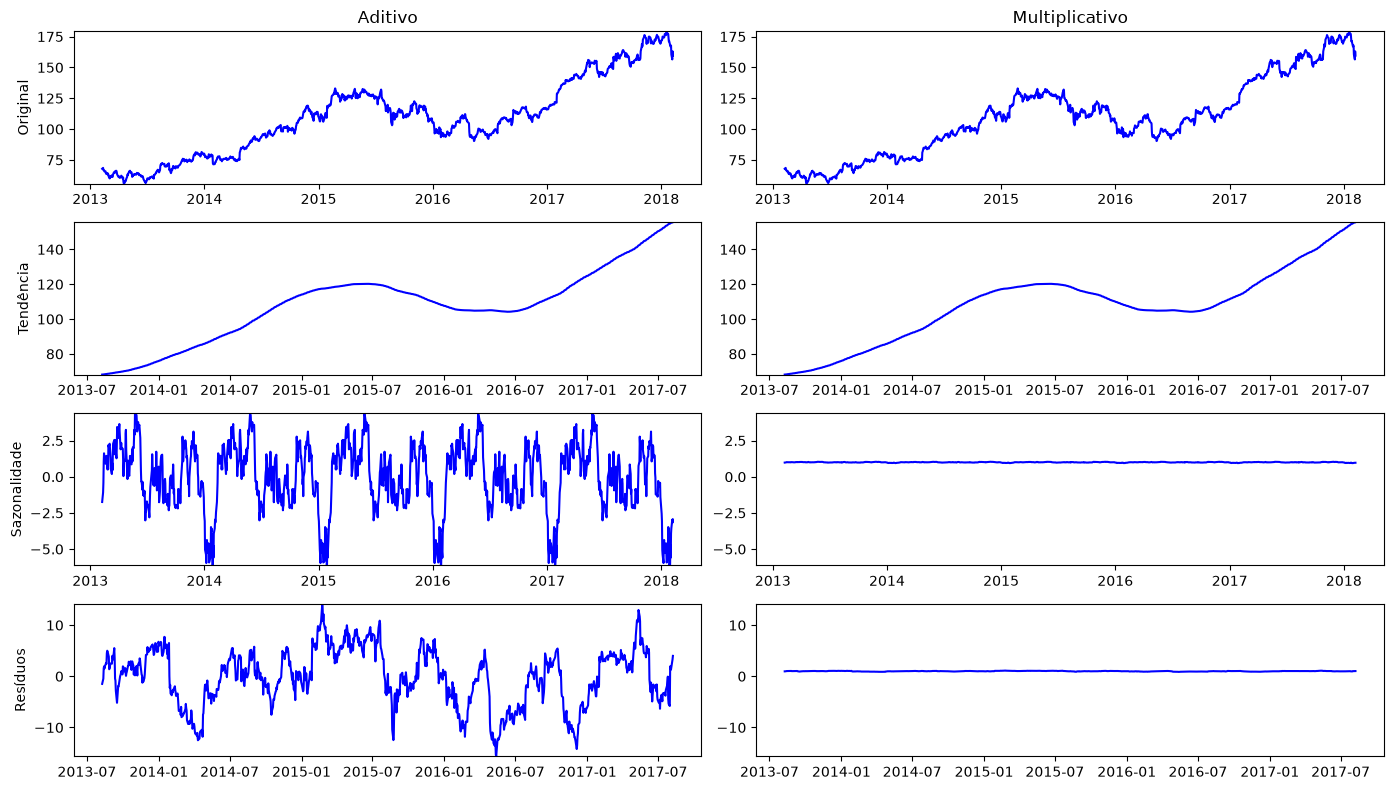

In [58]:
addit_decomp = seasonal_decompose(ts, model='additive', period=252) # numero de dias uteis no ano
mult_decomp = seasonal_decompose(ts, model='multiplicative', period=252) # numero de dias uteis no ano

min_orig = min(addit_decomp.observed.min(), mult_decomp.observed.min())
max_orig = max(addit_decomp.observed.max(), mult_decomp.observed.max())

min_tend = min(addit_decomp.trend.min(), mult_decomp.trend.min())
max_tend = max(addit_decomp.trend.max(), mult_decomp.trend.max())

min_sazon = min(addit_decomp.seasonal.min(), mult_decomp.seasonal.min())
max_sazon = max(addit_decomp.seasonal.max(), mult_decomp.seasonal.max())

min_resid = min(addit_decomp.resid.min(), mult_decomp.resid.min())
max_resid = max(addit_decomp.resid.max(), mult_decomp.resid.max())

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 8))
axes[0,0].plot(addit_decomp.observed, color="blue")
axes[0,0].set(ylabel="Original")
axes[0,0].set_ylim(min_orig,max_orig)
axes[1,0].plot(addit_decomp.trend, color="blue")
axes[1,0].set(ylabel="Tendência")
axes[1,0].set_ylim(min_tend, max_tend)
axes[2,0].plot(addit_decomp.seasonal, color="blue")
axes[2,0].set(ylabel="Sazonalidade")
axes[2,0].set_ylim(min_sazon, max_sazon)
axes[3,0].plot(addit_decomp.resid, color="blue")
axes[3,0].set(ylabel="Resíduos")
axes[3,0].set_ylim(min_resid, max_resid)
axes[0,0].set_title("Aditivo")

axes[0,1].plot(mult_decomp.observed, color="blue")
axes[0,1].set_ylim(min_orig,max_orig)
axes[1,1].plot(mult_decomp.trend, color="blue")
axes[1,1].set_ylim(min_tend, max_tend)
axes[2,1].plot(mult_decomp.seasonal, color="blue")
axes[2,1].set_ylim(min_sazon, max_sazon)
axes[3,1].plot(mult_decomp.resid, color="blue")
axes[3,1].set_ylim(min_resid, max_resid)
axes[0,1].set_title("Multiplicativo")

plt.tight_layout()
plt.show()

# sazonalidade e residuos do multiplicativo variam quase nada enquanto no aditvo tao bem mais espalhados
# o que indica que o aditivo é melhor para esses dados

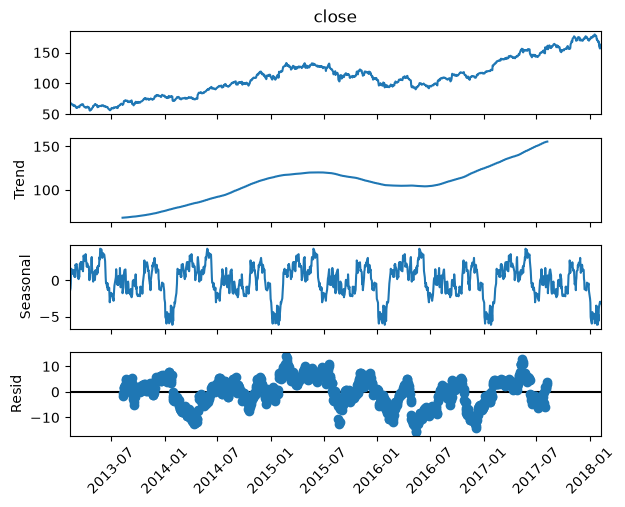

In [61]:
addit_decomp.plot()
plt.xticks(rotation=45)
plt.show()

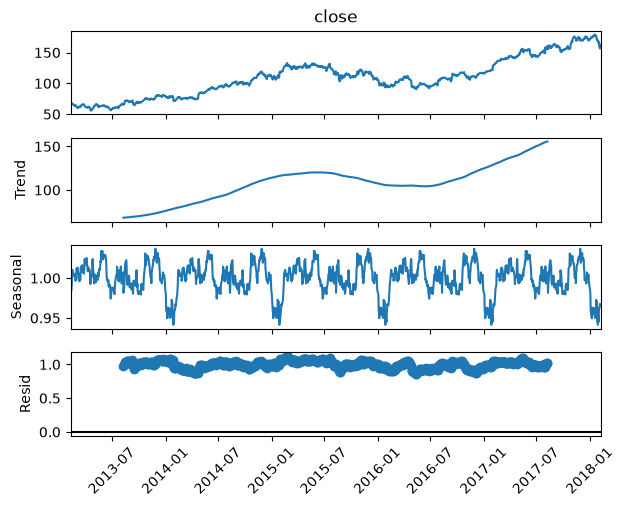

In [62]:
mult_decomp.plot()
plt.xticks(rotation=45)
plt.show()

# DECOMPOSICAO VIA STL

In [65]:
stl_result = STL(ts, period=252, robust=True).fit()

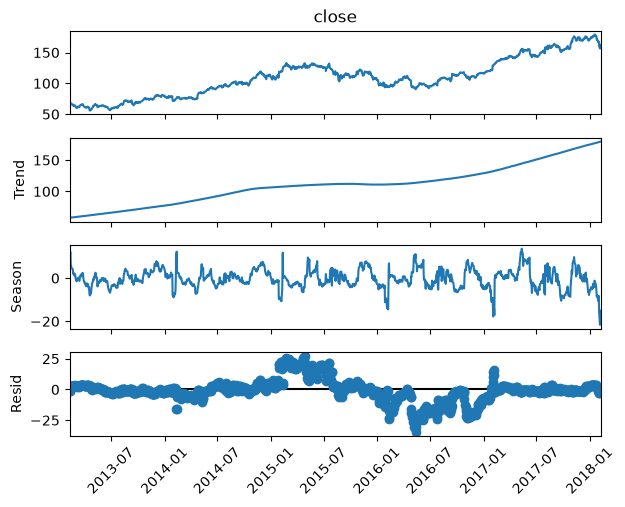

In [64]:
stl_result.plot()
plt.xticks(rotation=45)
plt.show()